In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold
from joblib import Parallel, delayed, dump, load
from extracter import *
from fitting_model import *
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)
mpl.rcParams.update({
    "font.family": "Arial",          
    "font.size": 8,

    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

In [2]:
fold_nums = [0,1,2,3,4]
num_ft = 36
rep = 3
all_targets = {}
all_states = {}
real_targets = {}
gamma='10' #that is .1
column_name = 'PQ-15'
all_targets, all_states, real_targets = speech_5folds_extracter(column_name, gamma = gamma,rep = rep, fold_nums = fold_nums, num_ft=num_ft)

In [3]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from trainer import *
train_points = 395
delay_points = 5
observation = train_points + delay_points
results = {}
errors = []
holder = []

errors = train(all_targets, all_states, real_targets, train_points = train_points, delay_points = delay_points, fold_nums=fold_nums, num_ft=num_ft)
print(errors)
print(np.mean(errors))

(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.16, 0.11, 0.14, 0.15, 0.15]
[0.16, 0.11, 0.14, 0.15, 0.15]
0.14200000000000002


In [4]:
gammas = ['05', '10', '15', '20', '25']
reps = [1,3]
tau = 15
fold_nums = [0,1,2,3,4]
num_ft = 36
performance= {}
column_name = 'PQ-15'
train_points = 395
delay_points = 5
rep1_errors=[]
rep3_errors=[]

for gamma in gammas:
    all_targets, all_states, real_targets = speech_5folds_extracter(column_name, gamma = gamma,rep = 1, fold_nums = fold_nums, num_ft=num_ft)
    errors = train(all_targets, all_states, real_targets, train_points = train_points, delay_points = delay_points, fold_nums=fold_nums, num_ft=num_ft)
    rep1_errors.append(errors)

    all_targets, all_states, real_targets = speech_5folds_extracter(column_name, gamma = gamma,rep = 3, fold_nums = fold_nums, num_ft=num_ft)
    errors = train(all_targets, all_states, real_targets, train_points = train_points, delay_points = delay_points, fold_nums=fold_nums, num_ft=num_ft)
    rep3_errors.append(errors)

(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.17, 0.14, 0.3, 0.25, 0.25]
(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.13, 0.16, 0.17, 0.16, 0.25]
(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.22, 0.16, 0.23, 0.19, 0.22]
(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.16, 0.11, 0.14, 0.15, 0.15]
(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.22, 0.16, 0.21, 0.19, 0.24]
(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.18, 0.15, 0.16, 0.18, 0.22]
(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.24, 0.2, 0.17, 0.17, 0.25]
(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.17, 0.15, 0.16, 0.16, 0.23]
(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.22, 0.15, 0.19, 0.16, 0.27]
(395, 144)
(395, 144)
(395, 144)
(395, 144)
(395, 144)
  [0.2, 0.14, 0.18, 0.2, 0.24]


In [5]:
reps = [1, 3]
tau_feature = 0
gammas = [.05, .1, .15, .2, .25]
x = np.arange(len(gammas))
rep1_errors_mean = np.array([np.mean(e) for e in rep1_errors])
rep1_errors_std  = np.array([np.std(e, ddof=1) for e in rep1_errors])

rep3_errors_mean = np.array([np.mean(e) for e in rep3_errors])
rep3_errors_std  = np.array([np.std(e, ddof=1) for e in rep3_errors])


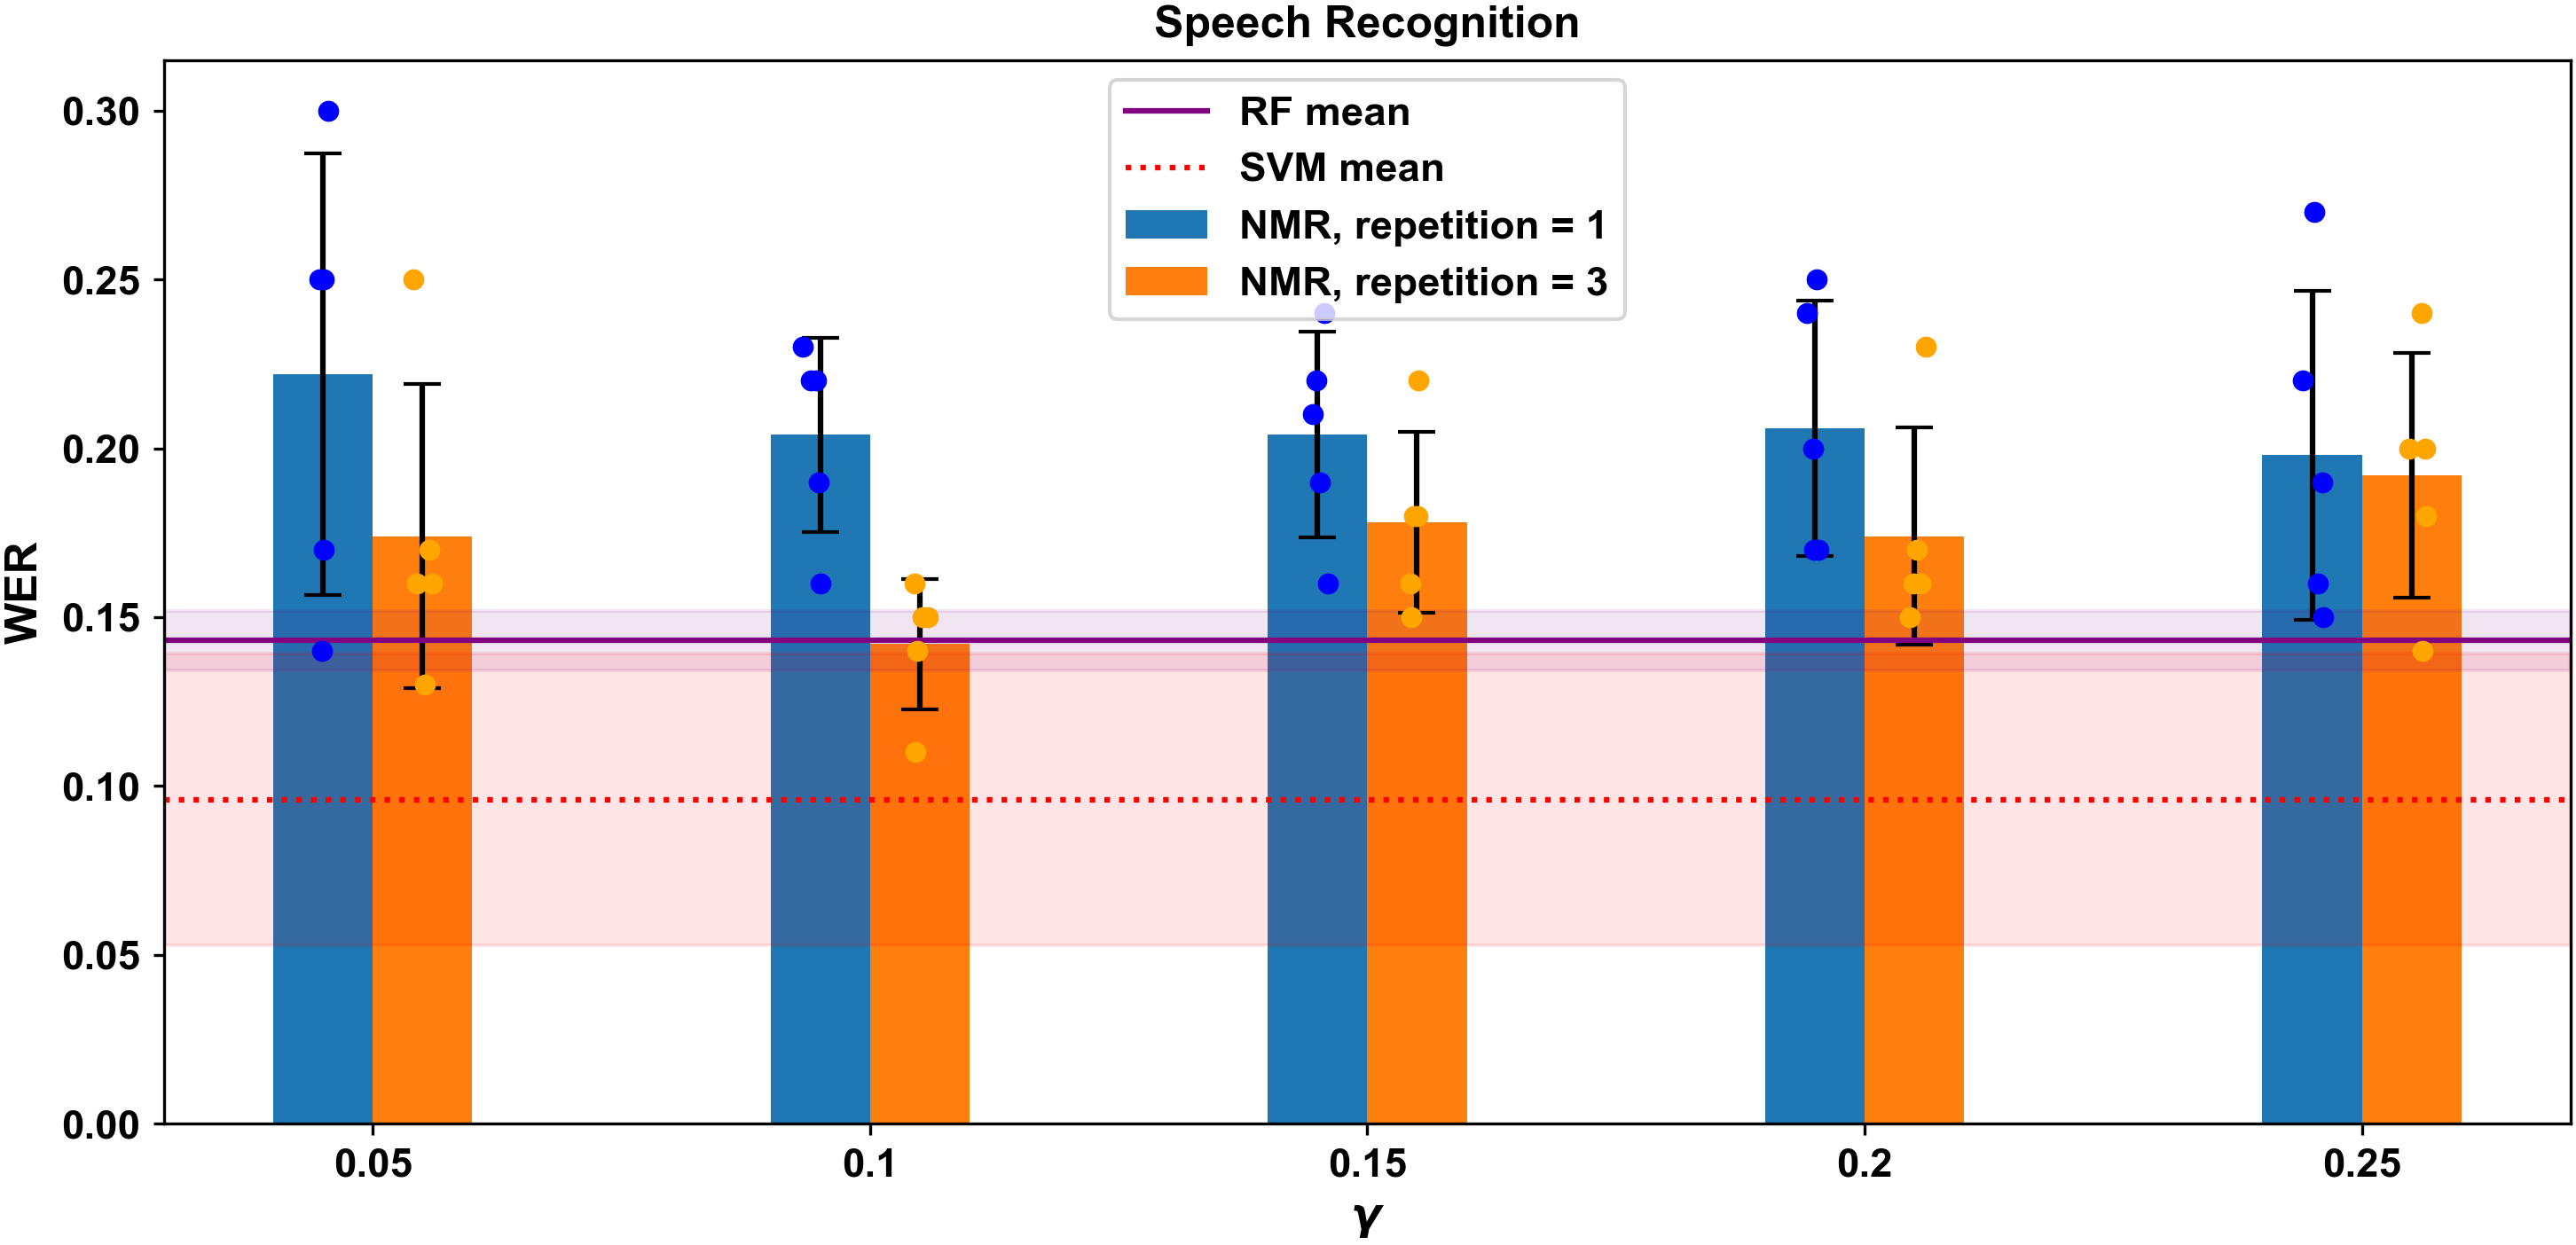

In [6]:
plt.figure(figsize=(10, 5))
width = .2
plt.bar(x - width/2,rep1_errors_mean,width,
    yerr=rep1_errors_std,capsize=5,label="NMR, repetition = 1")
plt.bar(x+ width/2,rep3_errors_mean, width,
    yerr=rep3_errors_std,capsize=5,label="NMR, repetition = 3")
rng = np.random.default_rng(0)

for i, task in enumerate(gammas):
    # QR rep = 1 rolling-window points
    jitter = rng.normal(0, 0.015, size=len(rep1_errors[i]))
    plt.scatter(np.full(len(rep1_errors[i]), x[i] - width/2) + jitter,
        rep1_errors[i],s=22,zorder=3,color="blue")

    # QR rep = 10 rolling-window points
    jitter = rng.normal(0, 0.015, size=len(rep3_errors[i]))
    plt.scatter(np.full(len(rep3_errors[i]), x[i]+ width/2) + jitter,
        rep3_errors[i],s=22,zorder=3,color='orange')

rf_mean = 0.14308
rf_std = 0.00878040489978006

svm_mean = 0.096
svm_std = 0.04326067433333767

plt.axhline(rf_mean, linestyle="-", label="RF mean",color = 'purple')
plt.axhspan(
    rf_mean - rf_std,
    rf_mean + rf_std,
    color = 'purple',
    alpha=0.1
)

plt.axhline(svm_mean, linestyle=":", label="SVM mean", color = 'red')
plt.axhspan(
    svm_mean - svm_std,
    svm_mean + svm_std,
    alpha=0.1,
    color = 'red'
)


plt.xticks(x, gammas)
plt.ylabel("WER")
plt.xlabel(r"$\gamma$")
plt.title("Speech Recognition")
plt.legend()
plt.tight_layout()
plt.savefig('speechrecognition.png')
plt.show()

In [7]:
rep3_errors_std

array([0.04505552, 0.01923538, 0.02683282, 0.03209361, 0.0363318 ])

In [8]:
rep3_errors_mean

array([0.174, 0.142, 0.178, 0.174, 0.192])